In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer

# load test set
test_df = pd.read_csv('../data/processed/test.csv')
test_df['clean_text'] = test_df['clean_text'].fillna('')
y_test = test_df['label']

# load baseline model and vectoriser
lr = joblib.load('../models/lr_model.pkl')
vectorizer = joblib.load('../models/tfidf_vectorizer.pkl')
X_test = vectorizer.transform(test_df['clean_text'])
baseline_preds = lr.predict(X_test)

# load distilbert predictions
distilbert_df = pd.read_csv('../data/processed/distilbert_predictions.csv')
distilbert_preds = distilbert_df['prediction'].values

print("data loaded")

data loaded


In [2]:
# build comparison table
def get_metrics(y_true, y_pred):
    return {
        'accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'precision': round(precision_score(y_true, y_pred, average='weighted'), 4),
        'recall':    round(recall_score(y_true, y_pred, average='weighted'), 4),
        'f1':        round(f1_score(y_true, y_pred, average='weighted'), 4)
    }

baseline_metrics   = get_metrics(y_test, baseline_preds)
distilbert_metrics = get_metrics(y_test, distilbert_preds)

comparison_df = pd.DataFrame({
    'TF-IDF + LR':  baseline_metrics,
    'DistilBERT':   distilbert_metrics
})

print(comparison_df)

# save comparison to results
os.makedirs('../results', exist_ok=True)
comparison_df.to_csv('../results/model_comparison.csv')
print("\nsaved to results/model_comparison.csv")

           TF-IDF + LR  DistilBERT
accuracy        0.9413      0.9813
precision       0.9415      0.9813
recall          0.9413      0.9813
f1              0.9413      0.9813

saved to results/model_comparison.csv


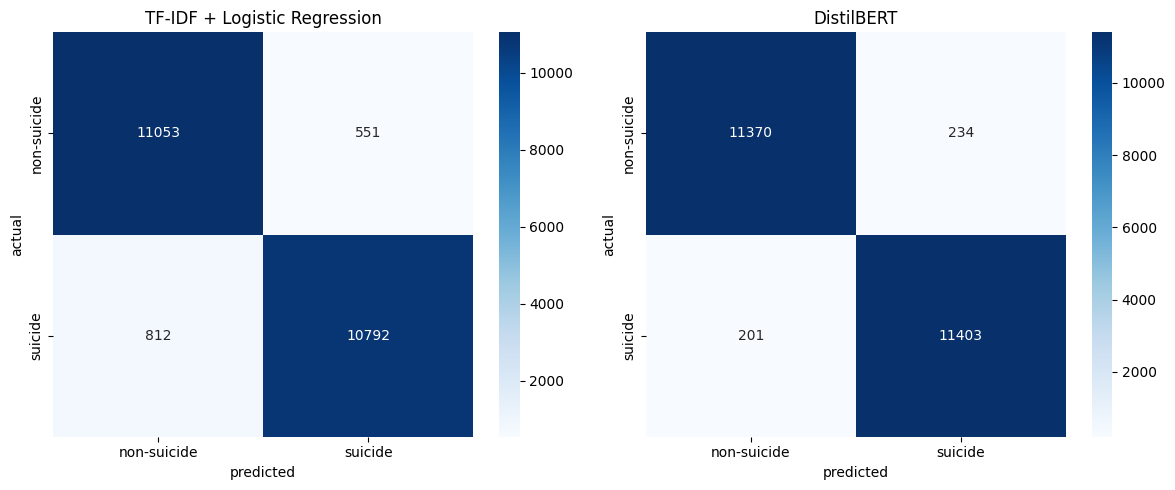

saved to results/confusion_matrix_comparison.png


In [3]:
# plot both confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(
    axes,
    [baseline_preds, distilbert_preds],
    ['TF-IDF + Logistic Regression', 'DistilBERT']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['non-suicide', 'suicide'],
                yticklabels=['non-suicide', 'suicide'])
    ax.set_xlabel('predicted')
    ax.set_ylabel('actual')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('../results/confusion_matrix_comparison.png', dpi=150)
plt.show()
print("saved to results/confusion_matrix_comparison.png")